# Indian Pines Hyperspectral Image Classification

**Data Mining and Analysis final project notebook**

This notebook follows a complete data-mining workflow for the Indian Pines hyperspectral image dataset:

1. **Data collection and visualization**: load the raw `.mat` cube, remove known water-absorption/noisy bands, inspect the cleaned cube, visualize pseudo-RGB imagery, ground truth, class balance, spectra, and band correlation.
2. **Data cleaning and quality audit**: remove unlabeled pixels, check missing/null and infinite values, define a median-filling strategy, inspect duplicate rows, and diagnose outliers with the IQR rule.
3. **Preprocessing and embedding**: use median imputation, scaling, PCA as a low-dimensional spectral embedding, and explain why one-hot encoding is not applied to the numeric spectral bands.
4. **Modeling and evaluation**: compare baseline, KNN, Random Forest, Gradient Boosting, and SVM models using stratified train/test splitting, cross-validation, F1-scores, and confusion matrices.
5. **Interpretation and justification**: explain class imbalance, PCA, model choices, errors, tuning results, and limitations.

The dataset is the **Indian Pines** hyperspectral image. Each labeled pixel is treated as one observation. The raw cube has 220 spectral bands; after removing known noisy and water-absorption bands, each labeled pixel has 200 cleaned numerical features.


## 0. Import Libraries and Configuration

We import the libraries used for numerical analysis, visualization, preprocessing, modeling, evaluation, cross-validation, and hyperparameter tuning.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV,
    GridSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")
plt.style.use("default")

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_COMPONENTS = 20
FAST_MODE = True  # Set to False if you want a larger hyperparameter search.

ROOT = Path.cwd()
DATA_DIR = ROOT / "Indian Pines"
OUTPUT_DIR = ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
CLASS_NAMES = {
    1: "Alfalfa",
    2: "Corn-notill",
    3: "Corn-mintill",
    4: "Corn",
    5: "Grass-pasture",
    6: "Grass-trees",
    7: "Grass-pasture-mowed",
    8: "Hay-windrowed",
    9: "Oats",
    10: "Soybean-notill",
    11: "Soybean-mintill",
    12: "Soybean-clean",
    13: "Wheat",
    14: "Woods",
    15: "Buildings-Grass-Trees-Drives",
    16: "Stone-Steel-Towers",
}

class_labels = sorted(CLASS_NAMES)
CLASS_NAMES


{1: 'Alfalfa',
 2: 'Corn-notill',
 3: 'Corn-mintill',
 4: 'Corn',
 5: 'Grass-pasture',
 6: 'Grass-trees',
 7: 'Grass-pasture-mowed',
 8: 'Hay-windrowed',
 9: 'Oats',
 10: 'Soybean-notill',
 11: 'Soybean-mintill',
 12: 'Soybean-clean',
 13: 'Wheat',
 14: 'Woods',
 15: 'Buildings-Grass-Trees-Drives',
 16: 'Stone-Steel-Towers'}

## 1. Dataset Description

The Indian Pines dataset is a well-known benchmark for hyperspectral image classification. It was collected over an agricultural area in north-western Indiana. The raw cube contains 220 bands. In this project, the raw cube is loaded first, then the known noisy and water-absorption bands are removed as an explicit cleaning step. The resulting 200-band cube is verified to match the provided `Indian_pines_corrected.mat` reference file.

In this project:

- The raw hyperspectral cube is the original feature source.
- The cleaned 200-band cube is used for exploration, preprocessing, and modeling.
- The ground-truth map is the target label source.
- Label `0` means unlabeled background and is excluded from model training.
- Labels `1` to `16` represent land-cover classes.


In [ ]:
# Load MATLAB files and perform the standard Indian Pines band-cleaning step.
raw_cube = loadmat(DATA_DIR / "Indian_pines.mat")["indian_pines"]
corrected_reference_cube = loadmat(DATA_DIR / "Indian_pines_corrected.mat")["indian_pines_corrected"]
gt = loadmat(DATA_DIR / "Indian_pines_gt.mat")["indian_pines_gt"]

# Published Indian Pines bad-band ranges are 1-based: 104-108, 150-163, and 220.
BAD_BANDS_1BASED = list(range(104, 109)) + list(range(150, 164)) + [220]
BAD_BANDS_0BASED = [band - 1 for band in BAD_BANDS_1BASED]
KEEP_BANDS_0BASED = [
    band_index
    for band_index in range(raw_cube.shape[2])
    if band_index not in BAD_BANDS_0BASED
]

cube = raw_cube[:, :, KEEP_BANDS_0BASED]
matches_corrected_reference = np.array_equal(cube, corrected_reference_cube)

print("Raw cube shape:", raw_cube.shape)
print("Cleaned cube shape:", cube.shape)
print("Ground truth shape:", gt.shape)
print("Removed raw bands:", BAD_BANDS_1BASED)
print("Cleaned cube matches Indian_pines_corrected.mat:", matches_corrected_reference)
print("Cube data type:", cube.dtype)
print("Minimum reflectance value:", cube.min())
print("Maximum reflectance value:", cube.max())
print("Number of labeled pixels:", np.sum(gt > 0))
print("Number of unlabeled pixels:", np.sum(gt == 0))


In [ ]:
dataset_summary = pd.DataFrame({
    "Property": [
        "Image height",
        "Image width",
        "Raw spectral bands",
        "Removed noisy/water-absorption bands",
        "Cleaned spectral bands used",
        "Matches corrected reference file",
        "Total pixels",
        "Labeled pixels",
        "Unlabeled pixels",
        "Number of classes",
    ],
    "Value": [
        cube.shape[0],
        cube.shape[1],
        raw_cube.shape[2],
        len(BAD_BANDS_1BASED),
        cube.shape[2],
        matches_corrected_reference,
        cube.shape[0] * cube.shape[1],
        int(np.sum(gt > 0)),
        int(np.sum(gt == 0)),
        len(CLASS_NAMES),
    ]
})

dataset_summary


## 2. Data Exploration

In this section, we visualize the hyperspectral image, inspect the ground-truth map, count class labels, and study spectral behavior.

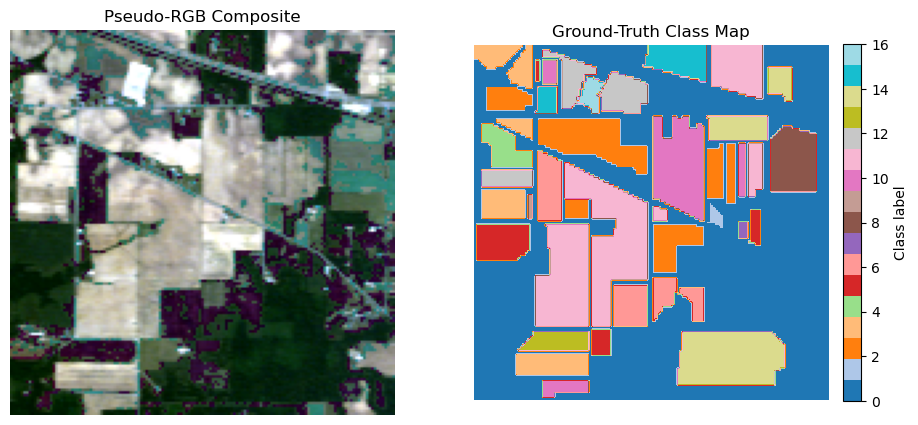

In [5]:
def make_pseudo_rgb(cube):
    """Create an approximate RGB image from selected hyperspectral bands."""
    selected_bands = [29, 19, 9]
    rgb = cube[:, :, selected_bands].astype(float)
    low = np.percentile(rgb, 2, axis=(0, 1))
    high = np.percentile(rgb, 98, axis=(0, 1))
    rgb = np.clip((rgb - low) / (high - low), 0, 1)
    return rgb

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(make_pseudo_rgb(cube))
axes[0].set_title("Pseudo-RGB Composite")
axes[0].axis("off")

im = axes[1].imshow(gt, cmap=plt.get_cmap("tab20", 17), vmin=0, vmax=16)
axes[1].set_title("Ground-Truth Class Map")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="Class label")
plt.show()


In [6]:
# Convert labeled pixels into tabular data: one row per labeled pixel, one column per band.
mask = gt > 0
X = cube[mask].reshape(-1, cube.shape[2]).astype(np.float32)
y = gt[mask].ravel().astype(int)

print("Feature matrix X:", X.shape)
print("Target vector y:", y.shape)


Feature matrix X: (10249, 200)
Target vector y: (10249,)


In [7]:
class_counts = pd.Series(y).value_counts().sort_index().rename_axis("class_id").reset_index(name="pixels")
class_counts["class_name"] = class_counts["class_id"].map(CLASS_NAMES)
class_counts = class_counts[["class_id", "class_name", "pixels"]]
class_counts


,class_id,class_name,pixels
0,1,Alfalfa,46
1,2,Corn-notill,1428
2,3,Corn-mintill,830
3,4,Corn,237
4,5,Grass-pasture,483
5,6,Grass-trees,730
6,7,Grass-pasture-mowed,28
7,8,Hay-windrowed,478
8,9,Oats,20
9,10,Soybean-notill,972


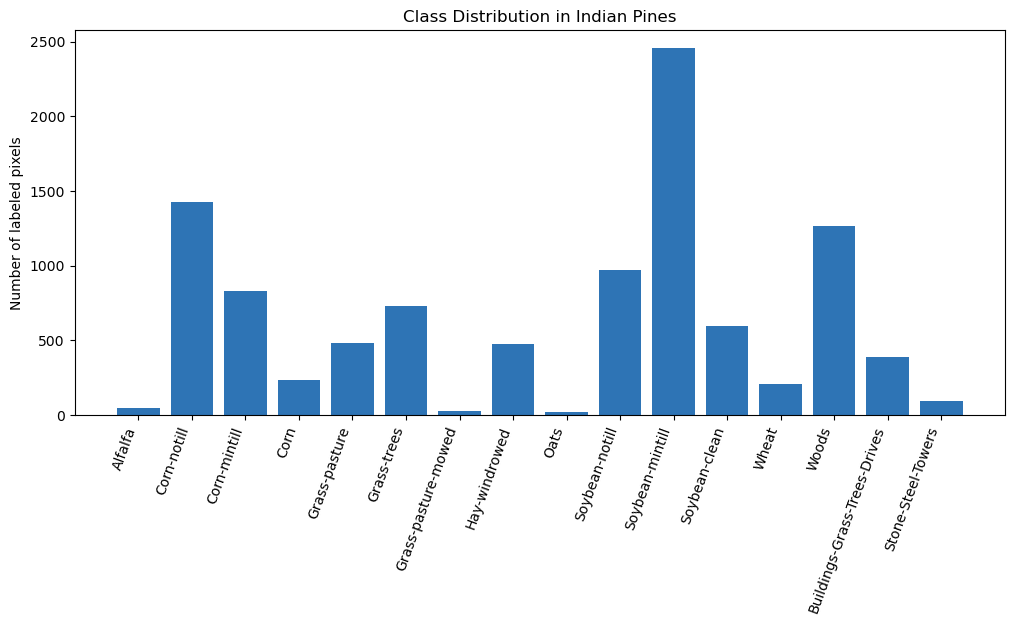

In [8]:
plt.figure(figsize=(12, 5))
plt.bar(class_counts["class_name"], class_counts["pixels"], color="#2E74B5")
plt.xticks(rotation=70, ha="right")
plt.ylabel("Number of labeled pixels")
plt.title("Class Distribution in Indian Pines")
plt.show()


### Exploration Comment

The class distribution is imbalanced. Some classes, such as **Soybean-mintill**, **Corn-notill**, and **Woods**, contain many pixels. Other classes, such as **Oats**, **Alfalfa**, and **Grass-pasture-mowed**, contain very few samples. This imbalance can make classification harder for the smaller classes.

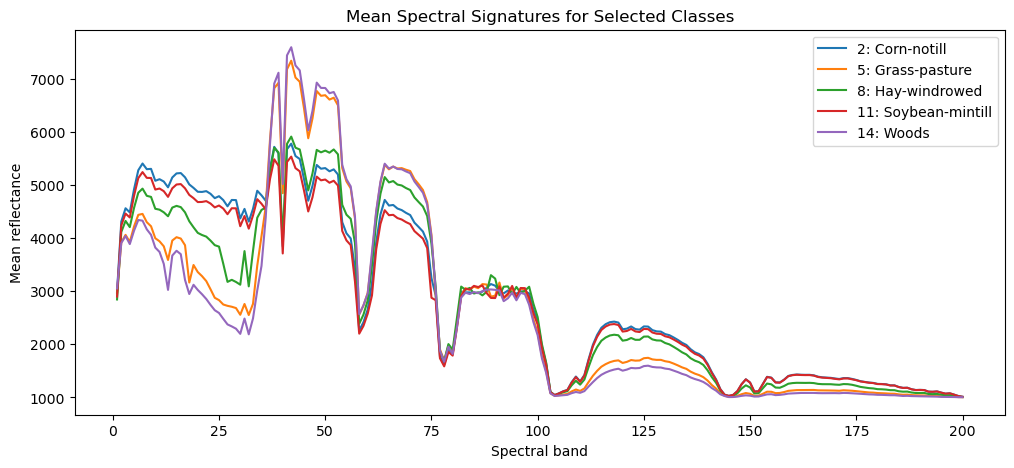

In [9]:
# Mean spectral signatures for selected classes
selected_classes = [2, 5, 8, 11, 14]
bands = np.arange(1, cube.shape[2] + 1)

plt.figure(figsize=(12, 5))
for label in selected_classes:
    spectra = X[y == label]
    plt.plot(bands, spectra.mean(axis=0), label=f"{label}: {CLASS_NAMES[label]}")

plt.xlabel("Spectral band")
plt.ylabel("Mean reflectance")
plt.title("Mean Spectral Signatures for Selected Classes")
plt.legend()
plt.show()


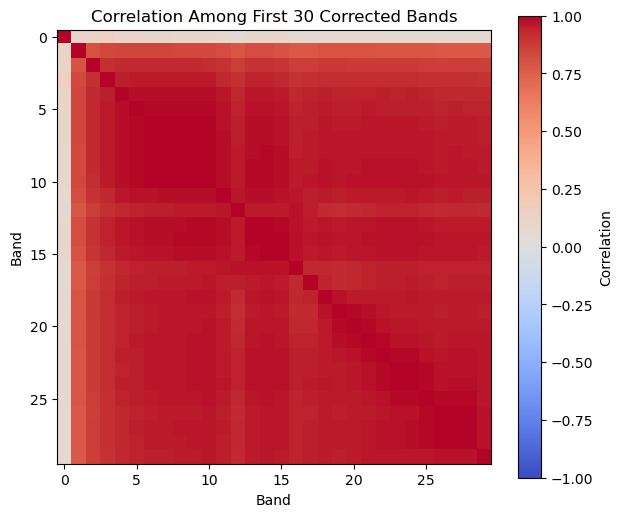

In [10]:
# Correlation among the first 30 bands
corr = np.corrcoef(X[:, :30], rowvar=False)

plt.figure(figsize=(7, 6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title("Correlation Among First 30 Corrected Bands")
plt.xlabel("Band")
plt.ylabel("Band")
plt.show()


### Correlation Comment

Many neighboring spectral bands are strongly correlated. This is expected in hyperspectral imaging because adjacent wavelengths often measure similar information. Because of this, PCA is useful for reducing redundant features.

## 3. Data Cleaning and Quality Audit

In this dataset, many values that look extreme may be valid crop or material spectra, so every cleaning decision must be justified.

The cleaning plan is:

1. Start from the raw 220-band cube and remove known noisy/water-absorption bands: `104-108`, `150-163`, and `220`.
2. Verify that the cleaned 200-band cube matches the provided `Indian_pines_corrected.mat` reference file.
3. Remove unlabeled pixels because label `0` is not a real land-cover class.
4. Check missing/null values and infinite values.
5. Define a filling method: median imputation, fitted only on the training data inside the model pipeline.
6. Check duplicate spectral rows.
7. Use the IQR rule to diagnose possible outliers band-by-band.
8. Keep IQR-flagged labeled pixels unless there is evidence that they are invalid, because removing them could destroy already-small classes.

The IQR rule flags a value as unusual when it is below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR`. Here it is used as a diagnostic method, not as an automatic deletion rule.


In [ ]:
# Band-removal, missing, infinite, label, and duplicate checks.
data_quality_summary = pd.DataFrame({
    "check": [
        "raw_spectral_bands",
        "removed_noisy_water_absorption_bands",
        "cleaned_spectral_bands",
        "matches_corrected_reference_file",
        "missing_values_in_X",
        "infinite_values_in_X",
        "unique_class_labels",
        "duplicate_spectral_rows",
    ],
    "result": [
        int(raw_cube.shape[2]),
        BAD_BANDS_1BASED,
        int(cube.shape[2]),
        bool(matches_corrected_reference),
        int(np.isnan(X).sum()),
        int(np.isinf(X).sum()),
        list(np.unique(y)),
        int(pd.DataFrame(X).duplicated().sum()),
    ],
})

data_quality_summary


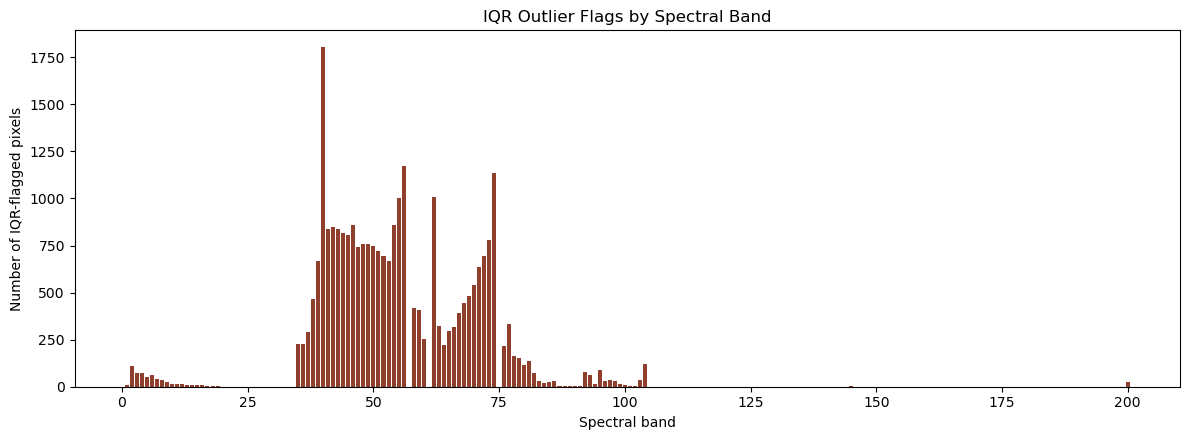

                         metric  value
                total_iqr_flags  27593
   bands_with_at_least_one_flag     91
  pixels_with_at_least_one_flag   2826
max_flagged_bands_for_one_pixel     67


,band,iqr_flagged_pixels
39,40,1803
55,56,1171
73,74,1133
61,62,1008
54,55,1005
45,46,858
53,54,858
41,42,849
40,41,840
42,43,838


In [12]:
# IQR outlier diagnostics computed independently for each spectral band.
q1 = np.percentile(X, 25, axis=0)
q3 = np.percentile(X, 75, axis=0)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

iqr_flags = (X < lower_bound) | (X > upper_bound)
iqr_flags_per_band = iqr_flags.sum(axis=0)
iqr_flags_per_sample = iqr_flags.sum(axis=1)

iqr_summary = pd.DataFrame({
    "metric": [
        "total_iqr_flags",
        "bands_with_at_least_one_flag",
        "pixels_with_at_least_one_flag",
        "max_flagged_bands_for_one_pixel",
    ],
    "value": [
        int(iqr_flags.sum()),
        int((iqr_flags_per_band > 0).sum()),
        int((iqr_flags_per_sample > 0).sum()),
        int(iqr_flags_per_sample.max()),
    ],
})

top_iqr_bands = pd.DataFrame({
    "band": np.arange(1, X.shape[1] + 1),
    "iqr_flagged_pixels": iqr_flags_per_band,
}).sort_values("iqr_flagged_pixels", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(np.arange(1, X.shape[1] + 1), iqr_flags_per_band, color="#8F3F2B")
ax.set_xlabel("Spectral band")
ax.set_ylabel("Number of IQR-flagged pixels")
ax.set_title("IQR Outlier Flags by Spectral Band")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "07_iqr_outlier_flags_by_band.png", dpi=200, bbox_inches="tight")
plt.show()

print(iqr_summary.to_string(index=False))
top_iqr_bands


### Band and Pixel Cleaning Visualization

The reference notebook uses band maps, pixel signatures, and pixel heatmaps to make hyperspectral data easier to understand. Here the same idea is adapted for the cleaning stage: the visualization is deterministic, uses the most frequently IQR-flagged band, and highlights one labeled pixel with many flagged bands. This supports the decision to treat IQR flags as diagnostics rather than automatic deletion rules.


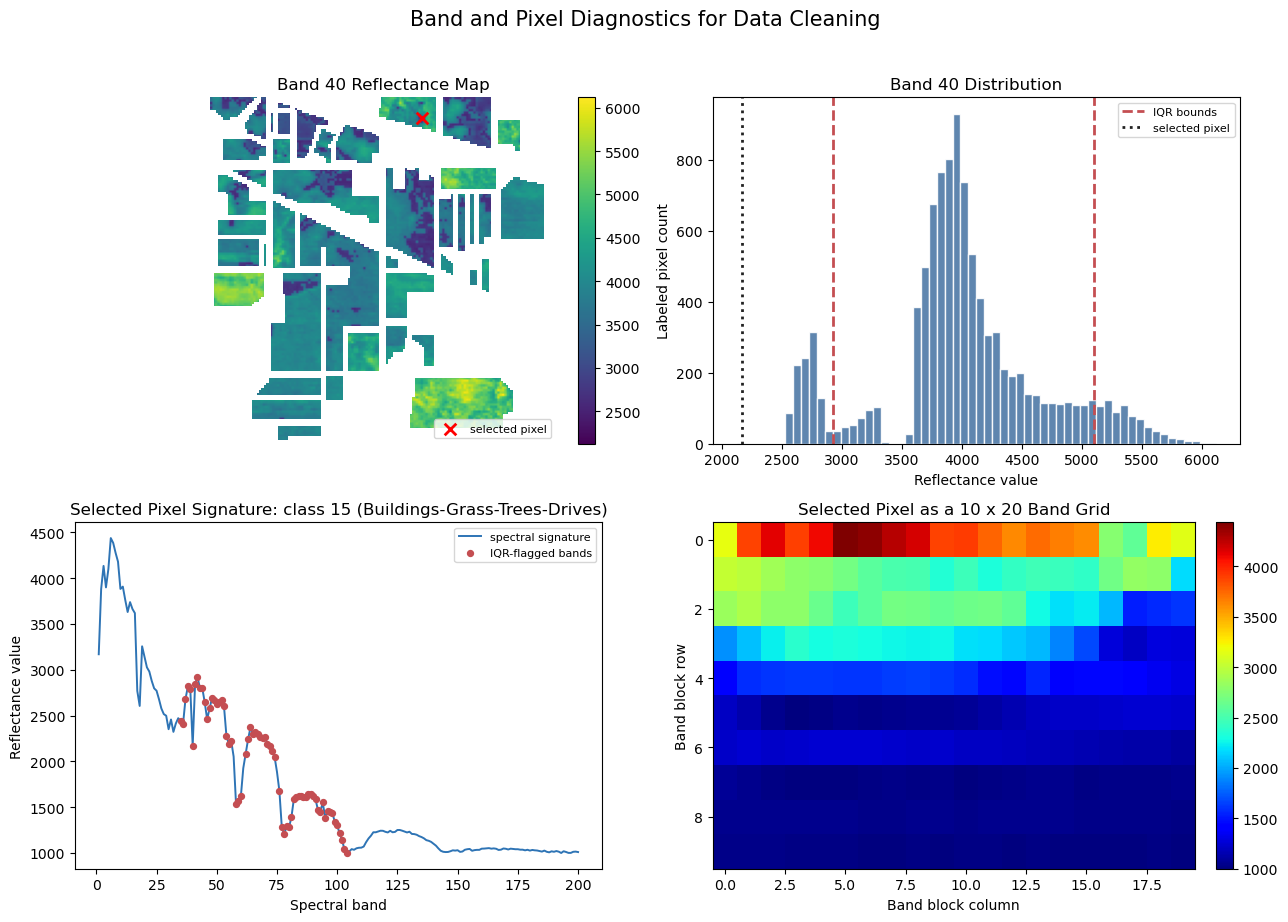

In [13]:
# Visual diagnostic inspired by band, pixel-signature, and pixel-heatmap views.
# The selected band and pixel are deterministic so the report can be reproduced.
top_band = int(top_iqr_bands.iloc[0]["band"])
top_band_index = top_band - 1
selected_sample_idx = int(np.argmax(iqr_flags_per_sample))
selected_spectrum = X[selected_sample_idx]
selected_label = int(y[selected_sample_idx])
selected_flags = iqr_flags[selected_sample_idx]
selected_row, selected_col = np.argwhere(mask)[selected_sample_idx]

band_image = cube[:, :, top_band_index].astype(float)
labeled_band_image = np.where(gt > 0, band_image, np.nan)
bands = np.arange(1, X.shape[1] + 1)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

im0 = axes[0, 0].imshow(labeled_band_image, cmap="viridis")
axes[0, 0].scatter(
    selected_col,
    selected_row,
    marker="x",
    s=70,
    linewidths=2,
    color="red",
    label="selected pixel",
)
axes[0, 0].set_title(f"Band {top_band} Reflectance Map")
axes[0, 0].axis("off")
axes[0, 0].legend(loc="lower right", fontsize=8)
fig.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)

axes[0, 1].hist(
    X[:, top_band_index],
    bins=60,
    color="#4E79A7",
    edgecolor="white",
    alpha=0.9,
)
axes[0, 1].axvline(lower_bound[top_band_index], color="#C44E52", linestyle="--", linewidth=2, label="IQR bounds")
axes[0, 1].axvline(upper_bound[top_band_index], color="#C44E52", linestyle="--", linewidth=2)
axes[0, 1].axvline(selected_spectrum[top_band_index], color="#222222", linestyle=":", linewidth=2, label="selected pixel")
axes[0, 1].set_title(f"Band {top_band} Distribution")
axes[0, 1].set_xlabel("Reflectance value")
axes[0, 1].set_ylabel("Labeled pixel count")
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(bands, selected_spectrum, color="#2E74B5", linewidth=1.4, label="spectral signature")
axes[1, 0].scatter(
    bands[selected_flags],
    selected_spectrum[selected_flags],
    color="#C44E52",
    s=18,
    label="IQR-flagged bands",
    zorder=3,
)
axes[1, 0].set_title(
    f"Selected Pixel Signature: class {selected_label} ({CLASS_NAMES[selected_label]})"
)
axes[1, 0].set_xlabel("Spectral band")
axes[1, 0].set_ylabel("Reflectance value")
axes[1, 0].legend(fontsize=8)

im3 = axes[1, 1].imshow(selected_spectrum.reshape(10, 20), cmap="jet", aspect="auto")
axes[1, 1].set_title("Selected Pixel as a 10 x 20 Band Grid")
axes[1, 1].set_xlabel("Band block column")
axes[1, 1].set_ylabel("Band block row")
fig.colorbar(im3, ax=axes[1, 1], fraction=0.046, pad=0.04)

fig.suptitle("Band and Pixel Diagnostics for Data Cleaning", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "08_band_pixel_cleaning_diagnostics.png", dpi=200, bbox_inches="tight")
plt.show()


### Cleaning Decision

There are no missing or infinite feature values in the corrected Indian Pines cube, so no actual value replacement is needed before modeling. However, the modeling pipeline still includes `SimpleImputer(strategy="median")` as the filling method. This is good practice because the imputer is fitted only on training folds, prevents data leakage, and makes the workflow robust if the dataset is changed later.

The IQR diagnostic flags some spectral values as unusual. They are not removed because hyperspectral reflectance naturally varies by land-cover material, and minority classes such as **Oats**, **Alfalfa**, and **Grass-pasture-mowed** already contain very few samples. Automatic outlier deletion would risk removing valid rare-class examples and making the classification problem less fair.


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)


Training set: (8199, 200) (8199,)
Test set: (2050, 200) (2050,)


In [15]:
train_counts = pd.Series(y_train).value_counts(normalize=True).sort_index()
test_counts = pd.Series(y_test).value_counts(normalize=True).sort_index()

split_balance = pd.DataFrame({
    "class_name": [CLASS_NAMES[i] for i in train_counts.index],
    "train_ratio": train_counts.values,
    "test_ratio": test_counts.values,
})

split_balance.head(10)


,class_name,train_ratio,test_ratio
0,Alfalfa,0.004513,0.004390
1,Corn-notill,0.139285,0.139512
2,Corn-mintill,0.080985,0.080976
3,Corn,0.023174,0.022927
4,Grass-pasture,0.047079,0.047317
5,Grass-trees,0.071228,0.071220
6,Grass-pasture-mowed,0.002805,0.002439
7,Hay-windrowed,0.046591,0.046829
8,Oats,0.001951,0.001951
9,Soybean-notill,0.094890,0.094634


## 4. Preprocessing, Encoding Decision, and PCA Embedding

The feature matrix contains 200 continuous spectral bands. These are numerical measurements, not categorical values, so **one-hot encoding is not applied to the input features**. One-hot encoding would be appropriate for categorical predictors such as crop region, sensor type, or soil category, but this dataset does not contain such columns.

The target labels are already integer class IDs from `1` to `16`, which is the correct format for the scikit-learn classifiers used here. A one-hot target matrix is shown only as a representation check; it is not used for these classical ML models.

The actual preprocessing pipeline is:

1. `SimpleImputer(strategy="median")` for missing-value filling if needed.
2. `StandardScaler()` to put bands on comparable scale.
3. `PCA(n_components=20)` to create a lower-dimensional spectral **embedding**.
4. Classifier.

PCA is the embedding method in this project: it transforms the original 200-band spectral vector into 20 compact components that preserve the strongest variance patterns.


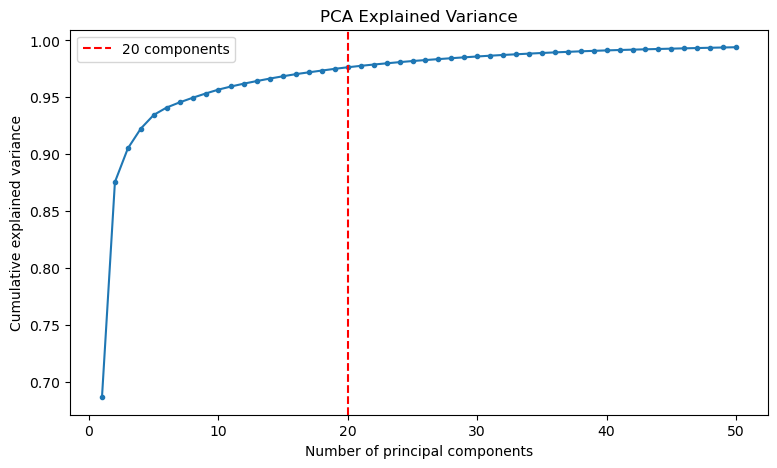

             step                                                                      decision
median_imputation       Included in pipelines; no values changed because missing count is zero.
  standardization           Applied before PCA/SVM/KNN so bands contribute on comparable scale.
 one_hot_encoding Not applied to features because all predictors are continuous spectral bands.
    pca_embedding                       Applied with 20 components; explained variance = 0.976.
One-hot target shape for inspection only: (10249, 16)


In [16]:
# One-hot target representation for inspection only; models use integer labels.
y_one_hot = pd.get_dummies(pd.Series(y, name="class_id"), prefix="class")

# Probe PCA explained variance using the same imputation and scaling logic as the pipelines.
preprocess_probe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

X_preprocessed = preprocess_probe.fit_transform(X)

pca_probe = PCA(n_components=50, random_state=RANDOM_STATE)
pca_probe.fit(X_preprocessed)

cum_var = np.cumsum(pca_probe.explained_variance_ratio_)

plt.figure(figsize=(9, 5))
plt.plot(np.arange(1, 51), cum_var, marker="o", markersize=3)
plt.axvline(N_COMPONENTS, color="red", linestyle="--", label=f"{N_COMPONENTS} components")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.show()

preprocessing_summary = pd.DataFrame({
    "step": ["median_imputation", "standardization", "one_hot_encoding", "pca_embedding"],
    "decision": [
        "Included in pipelines; no values changed because missing count is zero.",
        "Applied before PCA/SVM/KNN so bands contribute on comparable scale.",
        "Not applied to features because all predictors are continuous spectral bands.",
        f"Applied with {N_COMPONENTS} components; explained variance = {cum_var[N_COMPONENTS - 1]:.3f}.",
    ],
})

print(preprocessing_summary.to_string(index=False))
print("One-hot target shape for inspection only:", y_one_hot.shape)


## 5. Modeling: Baselines and Main Classifiers

We train and compare five models:

1. **Most Common Class baseline**: always predicts the majority class.
2. **k-Nearest Neighbors baseline**: predicts from nearby samples in PCA feature space.
3. **Random Forest Classifier**: an ensemble of decision trees.
4. **Gradient Boosting Classifier**: sequential trees that correct previous errors.
5. **Support Vector Machine**: finds nonlinear class boundaries in high-dimensional feature space.

The baselines are important because they show whether the advanced models actually add value. The main preprocessing pipeline is:

`SimpleImputer -> StandardScaler -> PCA -> Classifier`

This keeps filling, scaling, and embedding inside cross-validation and train/test evaluation, which prevents data leakage.


In [17]:
models = {
    "Most Common Class": DummyClassifier(strategy="most_frequent"),
    "k-Nearest Neighbors": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)),
        ("model", KNeighborsClassifier(n_neighbors=5)),
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)),
        ("model", RandomForestClassifier(
            n_estimators=80,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=1,
        )),
    ]),
    "Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)),
        ("model", GradientBoostingClassifier(
            n_estimators=45,
            learning_rate=0.10,
            max_depth=3,
            random_state=RANDOM_STATE,
        )),
    ]),
    "Support Vector Machine": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)),
        ("model", SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced")),
    ]),
}

models


{'Most Common Class': DummyClassifier(strategy='most_frequent'),
 'k-Nearest Neighbors': Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                 ('scaler', StandardScaler()),
                 ('pca', PCA(n_components=20, random_state=42)),
                 ('model', KNeighborsClassifier())]),
 'Random Forest': Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                 ('scaler', StandardScaler()),
                 ('pca', PCA(n_components=20, random_state=42)),
                 ('model',
                  RandomForestClassifier(class_weight='balanced',
                                         n_estimators=80, n_jobs=1,
                                         random_state=42))]),
 'Gradient Boosting': Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                 ('scaler', StandardScaler()),
                 ('pca', PCA(n_components=20, random_state=42)),
                 ('model',
                  GradientBoostingClassifi

In [18]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_test, y_pred, labels=class_labels)
    
    results[name] = {
        "model": model,
        "predictions": y_pred,
        "accuracy": acc,
        "report": report,
        "confusion_matrix": cm,
    }
    
    print(f"{name} accuracy: {acc:.3f}")


Most Common Class accuracy: 0.240
k-Nearest Neighbors accuracy: 0.749
Random Forest accuracy: 0.796
Gradient Boosting accuracy: 0.753
Support Vector Machine accuracy: 0.812


In [19]:
model_summary = pd.DataFrame([
    {
        "model": name,
        "test_accuracy": res["accuracy"],
        "macro_f1": res["report"]["macro avg"]["f1-score"],
        "weighted_f1": res["report"]["weighted avg"]["f1-score"],
    }
    for name, res in results.items()
]).sort_values("test_accuracy", ascending=False)

model_summary


,model,test_accuracy,macro_f1,weighted_f1
4,Support Vector Machine,0.811707,0.838844,0.812763
2,Random Forest,0.796098,0.762869,0.787367
3,Gradient Boosting,0.753171,0.679185,0.746138
1,k-Nearest Neighbors,0.748780,0.715444,0.739700
0,Most Common Class,0.239512,0.024154,0.092562


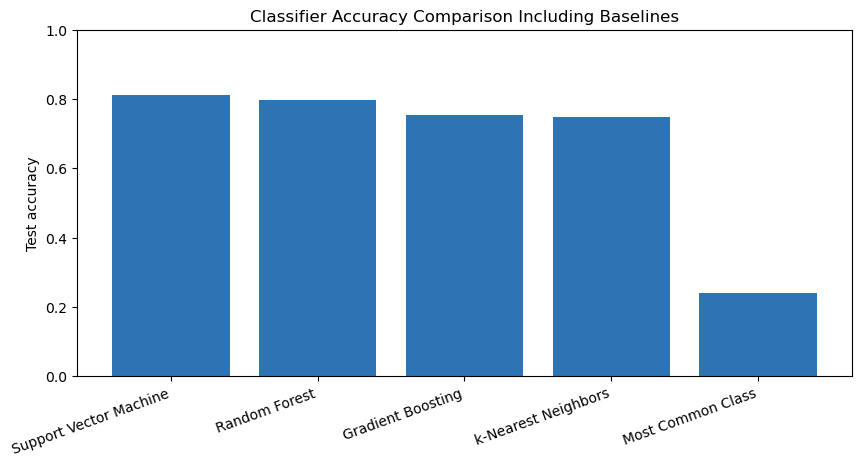

In [20]:
plt.figure(figsize=(10, 4.5))
plt.bar(model_summary["model"], model_summary["test_accuracy"], color="#2E74B5")
plt.ylim(0, 1)
plt.ylabel("Test accuracy")
plt.title("Classifier Accuracy Comparison Including Baselines")
plt.xticks(rotation=20, ha="right")
plt.show()


## 6. Model Evaluation with Confusion Matrices

The diagonal cells represent correct predictions. Values outside the diagonal represent misclassifications.

To keep the output readable, confusion matrices are shown for the three main classifiers. The baseline scores remain in the summary tables.

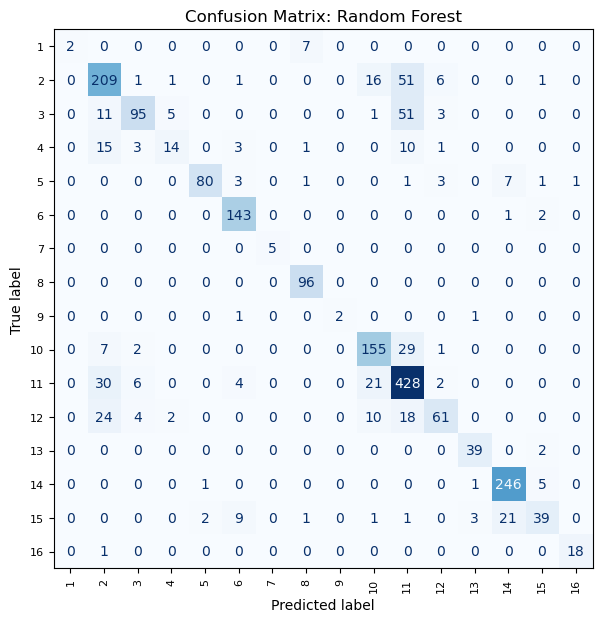

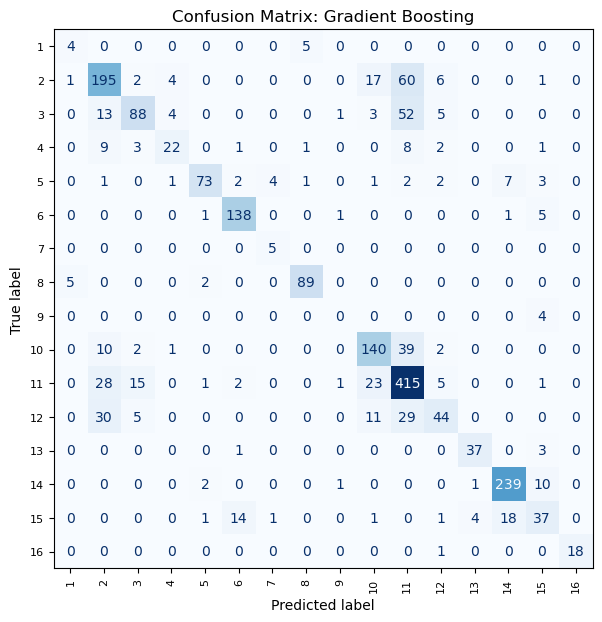

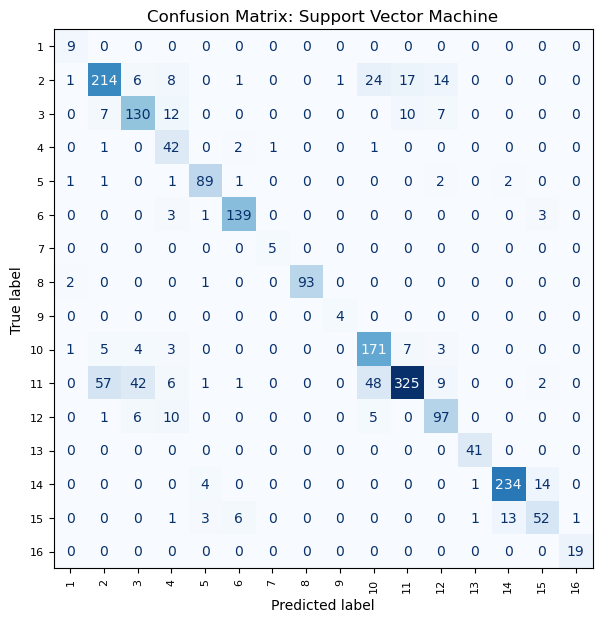

In [21]:
main_classifier_names = ["Random Forest", "Gradient Boosting", "Support Vector Machine"]

for name in main_classifier_names:
    res = results[name]
    fig, ax = plt.subplots(figsize=(8, 7))
    disp = ConfusionMatrixDisplay(res["confusion_matrix"], display_labels=class_labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(f"Confusion Matrix: {name}")
    ax.tick_params(axis="x", labelrotation=90, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    plt.show()


In [22]:
# Classification report for the best test model
best_model_name = model_summary.iloc[0]["model"]
best_predictions = results[best_model_name]["predictions"]

print("Best model:", best_model_name)
print(classification_report(y_test, best_predictions, target_names=[CLASS_NAMES[i] for i in class_labels], zero_division=0))


Best model: Support Vector Machine
                              precision    recall  f1-score   support

                     Alfalfa       0.64      1.00      0.78         9
                 Corn-notill       0.75      0.75      0.75       286
                Corn-mintill       0.69      0.78      0.73       166
                        Corn       0.49      0.89      0.63        47
               Grass-pasture       0.90      0.92      0.91        97
                 Grass-trees       0.93      0.95      0.94       146
         Grass-pasture-mowed       0.83      1.00      0.91         5
               Hay-windrowed       1.00      0.97      0.98        96
                        Oats       0.80      1.00      0.89         4
              Soybean-notill       0.69      0.88      0.77       194
             Soybean-mintill       0.91      0.66      0.76       491
               Soybean-clean       0.73      0.82      0.77       119
                       Wheat       0.95      1.00     

## 7. Cross-Validation

Cross-validation evaluates models across multiple train-validation splits. This gives a more stable performance estimate than only one test split.

Here we use 3-fold stratified cross-validation so each fold keeps approximately the same class proportions. The imputer, scaler, PCA embedding, and classifier are refit inside each fold through the pipeline, so validation data never influence preprocessing parameters.


In [23]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy", n_jobs=1)
    cv_results.append({
        "model": name,
        "cv_mean_accuracy": scores.mean(),
        "cv_std": scores.std(),
        "fold_scores": scores,
    })
    print(f"{name}: {scores.mean():.3f} +/- {scores.std():.3f}")

cv_summary = pd.DataFrame(cv_results).sort_values("cv_mean_accuracy", ascending=False)
cv_summary


Most Common Class: 0.240 +/- 0.000
k-Nearest Neighbors: 0.742 +/- 0.010
Random Forest: 0.782 +/- 0.006
Gradient Boosting: 0.740 +/- 0.008
Support Vector Machine: 0.804 +/- 0.008


,model,cv_mean_accuracy,cv_std,fold_scores
4,Support Vector Machine,0.804079,0.007892,"[0.793971319871232, 0.8050351288056206, 0.8132..."
2,Random Forest,0.781540,0.005617,"[0.7737781679836113, 0.7839578454332553, 0.786..."
1,k-Nearest Neighbors,0.742123,0.010308,"[0.7278314310798947, 0.7467798594847775, 0.751..."
3,Gradient Boosting,0.739976,0.007621,"[0.7304653204565408, 0.7491217798594848, 0.740..."
0,Most Common Class,0.239536,0.000157,"[0.23939127889961956, 0.23975409836065573, 0.2..."


In [24]:
comparison = model_summary.merge(cv_summary[["model", "cv_mean_accuracy", "cv_std"]], on="model")
comparison


,model,test_accuracy,macro_f1,weighted_f1,cv_mean_accuracy,cv_std
0,Support Vector Machine,0.811707,0.838844,0.812763,0.804079,0.007892
1,Random Forest,0.796098,0.762869,0.787367,0.781540,0.005617
2,Gradient Boosting,0.753171,0.679185,0.746138,0.739976,0.007621
3,k-Nearest Neighbors,0.748780,0.715444,0.739700,0.742123,0.010308
4,Most Common Class,0.239512,0.024154,0.092562,0.239536,0.000157


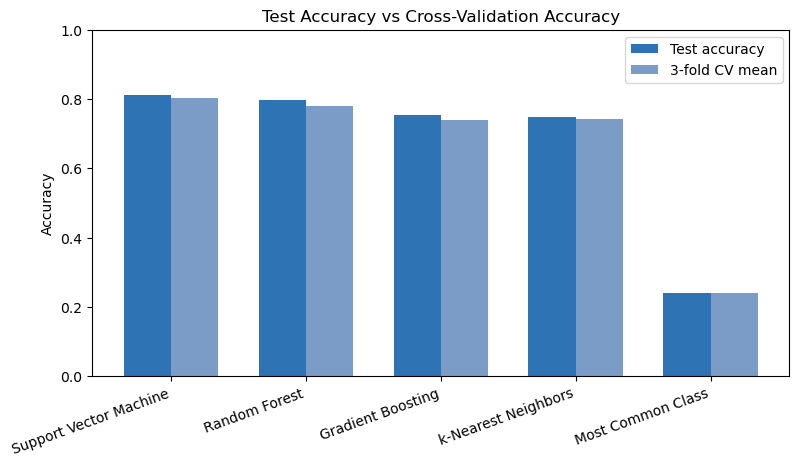

In [25]:
x = np.arange(len(comparison))
width = 0.35

plt.figure(figsize=(9, 4.5))
plt.bar(x - width/2, comparison["test_accuracy"], width, label="Test accuracy", color="#2E74B5")
plt.bar(x + width/2, comparison["cv_mean_accuracy"], width, label="3-fold CV mean", color="#7A9CC6")
plt.xticks(x, comparison["model"], rotation=20, ha="right")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Test Accuracy vs Cross-Validation Accuracy")
plt.legend()
plt.show()


## 8. Hyperparameter Tuning

Hyperparameters are model settings chosen before training. Tuning can improve performance by finding better settings.

Because Support Vector Machine was the strongest untuned model, the tuning stage focuses on SVM instead of Random Forest. This is more consistent with the experimental results: first compare several models, then tune the best candidate.

We tune the SVM classifier using:

- `RandomizedSearchCV`: tries a random sample of `C` and `gamma` combinations.
- `GridSearchCV`: checks a smaller manual grid centered around promising values.

The tuned estimator uses the same `SimpleImputer -> StandardScaler -> PCA -> SVC` pipeline as the untuned SVM. The search is intentionally compact when `FAST_MODE = True` so the notebook remains practical to run on a normal laptop.


In [ ]:
svm_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)),
    ("model", SVC(kernel="rbf", class_weight="balanced")),
])

if FAST_MODE:
    random_param_dist = {
        "model__C": [0.5, 1, 3, 10, 30, 100],
        "model__gamma": ["scale", 0.001, 0.003, 0.01, 0.03, 0.1],
    }
    random_iter = 10
    search_cv = 2
else:
    random_param_dist = {
        "model__C": [0.1, 0.5, 1, 3, 10, 30, 100, 300],
        "model__gamma": ["scale", "auto", 0.0005, 0.001, 0.003, 0.01, 0.03, 0.1],
    }
    random_iter = 24
    search_cv = 3

random_search = RandomizedSearchCV(
    svm_pipeline,
    random_param_dist,
    n_iter=random_iter,
    scoring="accuracy",
    cv=search_cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

random_search.fit(X_train, y_train)

print("Best randomized-search CV score:", random_search.best_score_)
print("Best randomized-search parameters:")
random_search.best_params_


In [ ]:
if FAST_MODE:
    grid_param = {
        "model__C": [3, 10, 30, 100],
        "model__gamma": ["scale", 0.003, 0.01, 0.03],
    }
    grid_cv = 2
else:
    grid_param = {
        "model__C": [10, 30, 100, 300],
        "model__gamma": ["scale", 0.003, 0.01, 0.03, 0.1],
    }
    grid_cv = 3

grid_search = GridSearchCV(
    svm_pipeline,
    grid_param,
    scoring="accuracy",
    cv=grid_cv,
    n_jobs=1,
)

grid_search.fit(X_train, y_train)

print("Best grid-search CV score:", grid_search.best_score_)
print("Best grid-search parameters:")
grid_search.best_params_


In [ ]:
tuned_svm = grid_search.best_estimator_
tuned_pred = tuned_svm.predict(X_test)
tuned_report = classification_report(
    y_test,
    tuned_pred,
    target_names=[CLASS_NAMES[i] for i in class_labels],
    output_dict=True,
    zero_division=0,
)
tuned_cm = confusion_matrix(y_test, tuned_pred, labels=class_labels)

tuned_svm_accuracy = accuracy_score(y_test, tuned_pred)
print("Tuned SVM test accuracy:", tuned_svm_accuracy)
print(classification_report(y_test, tuned_pred, target_names=[CLASS_NAMES[i] for i in class_labels], zero_division=0))

svm_tuning_results = {
    "model": "Support Vector Machine",
    "randomized_search": {
        "best_params": random_search.best_params_,
        "best_cv_accuracy": float(random_search.best_score_),
        "n_iter": random_iter,
        "cv": search_cv,
    },
    "grid_search": {
        "best_params": grid_search.best_params_,
        "best_cv_accuracy": float(grid_search.best_score_),
        "cv": grid_cv,
    },
    "test_accuracy": float(tuned_svm_accuracy),
    "macro_f1": float(tuned_report["macro avg"]["f1-score"]),
    "weighted_f1": float(tuned_report["weighted avg"]["f1-score"]),
    "confusion_matrix": tuned_cm.tolist(),
}

with open(OUTPUT_DIR / "svm_tuning_results.json", "w", encoding="utf-8") as f:
    json.dump(svm_tuning_results, f, indent=2)

svm_tuning_results


In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(tuned_cm, display_labels=class_labels).plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
    values_format="d",
)
ax.set_title("Confusion Matrix: Tuned Support Vector Machine")
ax.tick_params(axis="x", labelrotation=90, labelsize=8)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "12_cm_tuned_support_vector_machine.png", dpi=200, bbox_inches="tight")
plt.show()


In [ ]:
# Create spatial prediction map using the tuned SVM.
prediction_map = np.zeros(gt.shape, dtype=np.uint8)
prediction_map[mask] = tuned_svm.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(gt, cmap=plt.get_cmap("tab20", 17), vmin=0, vmax=16)
axes[0].set_title("Ground Truth")
axes[0].axis("off")

im = axes[1].imshow(prediction_map, cmap=plt.get_cmap("tab20", 17), vmin=0, vmax=16)
axes[1].set_title("Tuned SVM Prediction Map")
axes[1].axis("off")
plt.colorbar(im, ax=axes, fraction=0.025, pad=0.04, label="Class label")
plt.savefig(FIGURE_DIR / "11_prediction_map.png", dpi=200, bbox_inches="tight")
plt.show()


## 9. Interpretation and Conclusion

This project follows the full data-mining pipeline: data collection, visualization, cleaning, preprocessing, modeling, evaluation, and interpretation.

Main findings:

- The raw dataset has 145 x 145 pixels and 220 spectral bands; after removing known noisy/water-absorption bands, the cleaned modeling cube has 200 spectral bands.
- Only labeled pixels were used for classification; unlabeled pixels were excluded because label `0` is not a valid class.
- Missing and infinite checks returned zero problematic feature values. Median imputation is still included in pipelines as a leakage-safe filling method.
- IQR diagnostics reveal unusual spectral values, but they are retained because they can represent valid rare land-cover signatures.
- The class distribution is imbalanced, which affects performance on smaller classes.
- One-hot encoding is not used for features because the predictors are continuous spectral bands, not categorical fields.
- PCA is used as the embedding/dimensionality-reduction method because spectral bands are strongly correlated.
- The compared models were Most Common Class, k-Nearest Neighbors, Random Forest, Gradient Boosting, and Support Vector Machine.
- Cross-validation gives a more reliable estimate than a single test split.
- Hyperparameter tuning is applied to SVM because it is the strongest untuned model; the tuned setting `C=30` and `gamma=0.03` improves test accuracy from 81.17% to 83.07%.
- SVM performs best in this experiment because it handles high-dimensional, nonlinear spectral boundaries well after scaling and PCA.


In [ ]:
final_summary = comparison.copy()
final_summary["test_accuracy"] = final_summary["test_accuracy"].round(3)
final_summary["cv_mean_accuracy"] = final_summary["cv_mean_accuracy"].round(3)
final_summary["cv_std"] = final_summary["cv_std"].round(3)

project_summary = {
    "raw_dataset_shape": list(raw_cube.shape),
    "dataset_shape": list(cube.shape),
    "ground_truth_shape": list(gt.shape),
    "removed_noisy_water_absorption_bands_1based": BAD_BANDS_1BASED,
    "matches_corrected_reference_file": bool(matches_corrected_reference),
    "labeled_pixels": int(mask.sum()),
    "missing_values": int(np.isnan(X).sum()),
    "infinite_values": int(np.isinf(X).sum()),
    "iqr_total_flags": int(iqr_flags.sum()),
    "iqr_pixels_with_flags": int((iqr_flags_per_sample > 0).sum()),
    "preprocessing": [
        "remove known noisy/water-absorption bands from the raw 220-band cube",
        "median imputation inside pipelines",
        "standardization",
        "PCA embedding with 20 components",
        "no feature one-hot encoding because all predictors are numeric spectral bands",
    ],
    "model_comparison": final_summary.to_dict(orient="records"),
    "best_untuned_test_model": str(final_summary.sort_values("test_accuracy", ascending=False).iloc[0]["model"]),
    "tuned_support_vector_machine": svm_tuning_results,
}

with open(OUTPUT_DIR / "enhanced_data_mining_summary.json", "w", encoding="utf-8") as f:
    json.dump(project_summary, f, indent=2)

final_summary
